In [1]:
!git clone https://github.com/ArGintum/GPTID.git
!pip3 install pygsp
!rm human_gpt2_wikip.json_pp
!unzip GPTID/data/human_gpt2_wikip.zip
!mv human_gpt2_wikip.json_pp GPTID/data/human_gpt2_wikip.json_pp

Cloning into 'GPTID'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 41 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 21.52 MiB | 11.91 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [39]:

### Insert here path to model files in your syste,
model_path = 'roberta-base'
tokenizer_path = model_path

### Loading the model
tokenizer = RobertaTokenizer.from_pretrained(tokenizer_path)
model = RobertaModel.from_pretrained(model_path)


"""
Our method (PHD) is stochastic, here are some magic constants for it. They are chosen specifically for text data. If you plan to use this code for something different, consider testing other values.

MIN_SUBSAMPLE       --- the size of the minimal subsample to be drawn in procedure. Lesser values yields less statisitcally stable predictions.
INTERMEDIATE_POINTS --- number of sumsamples to be drawn. The more this number is, the more stable dimension estimation for single text is; however,  the computational time is higher, too. 7 is, empirically, the best trade-off.
"""
MIN_SUBSAMPLE = 40
INTERMEDIATE_POINTS = 7


'''
Auxillary function. Clear text from linebreaks and odd whitespaces, because they seem to interfer with LM quite a lot.
Replace with a more sophisticated cleaner, if needed.
'''

def preprocess_text(text):
    return text.replace('\n', ' ').replace('  ', ' ')


def decode_by_tokens(inputs):
    decoded_tokens = []
    for token in inputs['input_ids'].reshape(-1)[1:-1]:
        decoded_tokens.append(tokenizer.decode([token]))

    return decoded_tokens


def get_embeds(text, returns_tokenized=False):
    inputs = tokenizer(preprocess_text(text), truncation=True, max_length=512, return_tensors="pt")
    with torch.no_grad():
        outp = model(**inputs)

    if not returns_tokenized:
        return outp[0][0].numpy()[1:-1]

    return outp[0][0].numpy()[1:-1], decode_by_tokens(inputs)

'''
Get PHD for one text
Parameters:
        text  --- text
        solver --- PHD computator

Returns:
    real number or NumPy.nan  --- Intrinsic dimension value of the text in the input data
                                                    estimated by Persistence Homology Dimension method.'''
def get_phd_single(text, solver):
    inputs = tokenizer(preprocess_text(text), truncation=True, max_length=512, return_tensors="pt")
    with torch.no_grad():
        outp = model(**inputs)

    # We omit the first and last tokens (<CLS> and <SEP> because they do not directly correspond to any part of the)
    mx_points = inputs['input_ids'].shape[1] - 2


    mn_points = MIN_SUBSAMPLE
    step = ( mx_points - mn_points ) // INTERMEDIATE_POINTS

    return solver.fit_transform(outp[0][0].numpy()[1:-1],  min_points=mn_points, max_points=mx_points - step, \
                                point_jump=step)

'''
Get PHD for all texts in df[key] Pandas DataSeries (PHD method)
Parameters:
        df  --- Pandas DataFrame
        key --- Name of the column
        is_list --- Check if the elements of the df[key] are lists (appears in some data)

        alpha --- Parameter alpha for PHD computattion

Returns:
    numpy.array of shape (number_of_texts, 1) --- Intrinsic dimension values for all texts in the input data
                                                    estimated by Persistence Homology Dimension method.
'''

def get_phd(df, key='text', is_list=False, alpha=1.0, regression_type='vanilla'):
    dims = []
    PHD_solver = PHD(alpha=alpha, metric='euclidean', n_points=9)
    for s in tqdm(df[key]):
        if is_list:
            text = s[0]
        else:
            text = s
#         print("text ===============:", text)
        dims.append(get_phd_single(text, PHD_solver))

    return np.array(dims).reshape(-1, 1)


'''
Get MLE for one text
Parameters:
        text  --- text
        solver --- MLE computator

Returns:
    real number or NumPy.nan  --- Intrinsic dimension value of the text in the input data
                                                    estimated by Maximum Likelihood Estimation method.'''
def get_mle_single(text, solver):
    inputs = tokenizer(preprocess_text(text), truncation=True, max_length=512, return_tensors="pt")
    with torch.no_grad():
        outp = model(**inputs)

    return solver.fit_transform(outp[0][0].numpy()[1:-1])

'''
Get PHD for all texts in df[key] Pandas DataSeries (PHD method)
Parameters:
        df  --- Pandas DataFrame
        key --- Name of the column
        is_list --- Check if the elements of the df[key] are lists (appears in some data)

Returns:
    numpy.array of shape (number_of_texts, 1) --- Intrinsic dimension values for all texts in the input data
                                                    estimated by Maximum Likelihood Estimation method.
'''


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


'\nGet PHD for all texts in df[key] Pandas DataSeries (PHD method)\nParameters:\n        df  --- Pandas DataFrame\n        key --- Name of the column\n        is_list --- Check if the elements of the df[key] are lists (appears in some data)\n        \nReturns:\n    numpy.array of shape (number_of_texts, 1) --- Intrinsic dimension values for all texts in the input data\n                                                    estimated by Maximum Likelihood Estimation method.\n'

In [34]:
import umap
import plotly.express as px
import networkx as nx
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
import matplotlib.pyplot as plt


def visualize(sample_text, inverse_weights=False, show=True):

    embeds, inputs = get_embeds(sample_text, True)
    input2embed = pd.DataFrame({'inputs': inputs, 'embeds': embeds.tolist()})
    dist_matrix = np.zeros((embeds.shape[0], embeds.shape[0]))
    for i in range(embeds.shape[0]):
        for j in range(embeds.shape[0]):
            dist_matrix[i][j] = (((embeds[i, :] - embeds[j, :]) ** 2).sum()) ** 0.5
            if inverse_weights:
                dist_matrix[i][j] = 1 / dist_matrix[i][j] if dist_matrix[i][j] else 0

    Tcsr = minimum_spanning_tree(dist_matrix).todense()

    edges = list(zip(Tcsr.nonzero()[0], Tcsr.nonzero()[1]))
    reducer = umap.UMAP(random_state=139892)
    if show:
        embeddings = reducer.fit_transform(embeds)

        fig = px.scatter(
            embeddings,
            size_max=10,
            size=[0.3] * embeddings.shape[0],
            x=0,
            y=1,
            color=input2embed['inputs'],  # Shorten the legend text
            hover_name=input2embed['inputs'].apply(
                lambda x: x[:70]),  # Show full text on hover
            #   labels={'type_of_cluster': 'Shortened Message'}
        )

        for i, j in edges:
            if not inverse_weights:
                fig.add_shape(
                    type='line',
                    x0=embeddings[i,0], y0=embeddings[i,1],
                    x1=embeddings[j,0], y1=embeddings[j,1],
                    line=dict(color='gray', width=Tcsr[i, j] / 10),
                    layer='below'
                )
            else:
                fig.add_shape(
                    type='line',
                    x0=embeddings[i,0], y0=embeddings[i,1],
                    x1=embeddings[j,0], y1=embeddings[j,1],
                    line=dict(color='gray', width=Tcsr[i, j] * 10),
                    layer='below'
                )

        fig.show()

    return Tcsr, dist_matrix

In [35]:
import numpy as np
from pygsp import graphs
import pandas as pd

import torch
import torch.nn as nn

from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizer, RobertaModel
from tqdm import tqdm
from scipy.spatial.distance import cdist
from skdim.id import MLE

from tqdm import tqdm

from GPTID.IntrinsicDim import PHD


def get_max_eigenvalue(sample_text, show=False, inverse_weights=False):
    Tcsr, dist_matrix = visualize(sample_text, show=show, inverse_weights=inverse_weights)
    G = graphs.Graph(dist_matrix)
    # Gold.compute_fourier_basis()
    G.estimate_lmax()
    return G.lmax


sample_text = "Speaking of festivities, there is one day in China that stands unrivaled - the first day of the Lunar New Year, commonly referred to as the Spring Festival. Even if you're generally uninterested in celebratory events, it's hard to resist the allure of the family reunion dinner, a quintessential aspect of the Spring Festival. Throughout the meal, family members raise their glasses to toast one another, expressing wishes for happiness, peace, health, and prosperity in the upcoming year."
df = pd.DataFrame({'text': [sample_text]})
reddit_data = pd.read_json("GPTID/data/human_gpt2_wikip.json_pp", lines=True)

goldman_completion = []
gen_completion = []
for value in tqdm(reddit_data.iloc[0]):
#     print(value)
    goldman_completion.append(value['gold_completion'])
    gen_completion.append(value['gen_completion'])

reddit_data = pd.DataFrame({'gold_completion': goldman_completion, 'gen_completion': gen_completion})

n_samples = 50

100%|██████████| 2557/2557 [00:00<00:00, 633294.08it/s]


In [37]:
df = reddit_data.copy().sample(50)

gold_len = df['gold_completion'].apply(len)
gen_len = df['gen_completion'].apply(lambda x: len(x[0]))

lmax_gold = []
for gold_text in tqdm(df['gold_completion'].values.tolist()):
    lmax = get_max_eigenvalue(gold_text, False, False)
    lmax_gold.append(lmax)

lmax_gen = []
for gen_text in tqdm(df['gen_completion'].values.tolist()):
    lmax = get_max_eigenvalue(gen_text[0], False, False)
    lmax_gen.append(lmax)




100%|██████████| 50/50 [01:10<00:00,  1.41s/it]


100%|██████████| 50/50 [01:23<00:00,  1.67s/it]


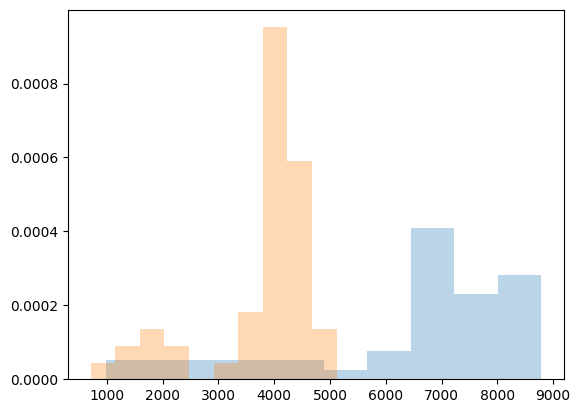

In [40]:
df_lmax = pd.DataFrame({'lmax_gold': lmax_gold, 'lmax_gen': lmax_gen})
phd_gold = get_phd(df, 'gold_completion')
phd_gen = get_phd(df, 'gen_completion', is_list=True)
df_all = pd.DataFrame(
    {
        'lmax_gold': lmax_gold,
        'lmax_gen': lmax_gen,
        'phd_gold': phd_gold.reshape(-1),
        'phd_gen': phd_gen.reshape(-1),
        'gold_len': gold_len,
        'gen_len': gen_len
    }
)


_ = plt.hist(lmax_gold, density=True, alpha=0.3)
_ = plt.hist(lmax_gen, density=True, alpha=0.3)



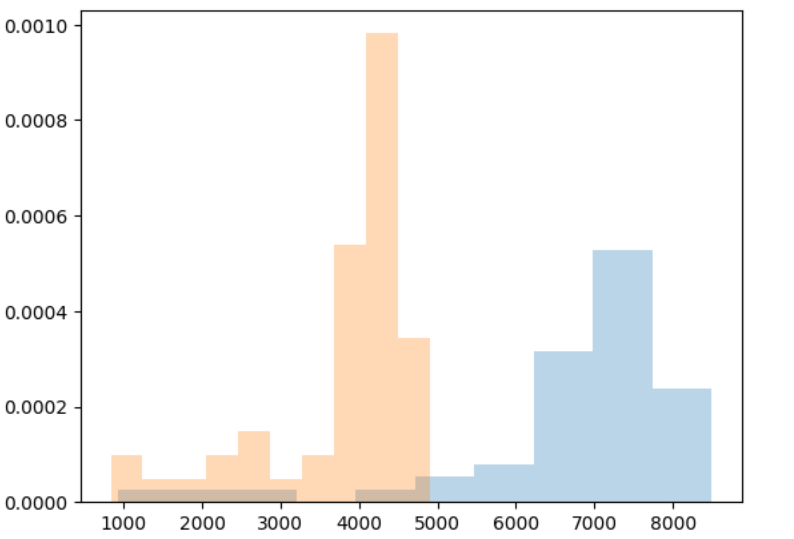

In [41]:
df_all.corr('pearson')

,lmax_gold,lmax_gen,phd_gold,phd_gen,gold_len,gen_len
lmax_gold,1.000000,-0.007999,0.044865,-0.104259,0.938314,0.002604
lmax_gen,-0.007999,1.000000,0.028551,-0.100181,-0.032416,0.917279
phd_gold,0.044865,0.028551,1.000000,-0.022280,0.145925,0.076274
phd_gen,-0.104259,-0.100181,-0.022280,1.000000,-0.049011,0.120321
gold_len,0.938314,-0.032416,0.145925,-0.049011,1.000000,0.010761
gen_len,0.002604,0.917279,0.076274,0.120321,0.010761,1.000000
